In [1]:
import os
import sys
sys.path.insert(0, '/home/aiscuser/verl')
import torch
from verl.third_party.sglang.entrypoint import CustomEngine
from verl.utils.dataset.rl_dataset import RLHFDataset, collate_fn
os.environ["SGLANG_BLOCK_NONZERO_RANK_CHILDREN"] = "0"
from transformers import AutoTokenizer, AutoProcessor
from uuid import uuid4
import time
import numpy as np
import random

/opt/conda/envs/ptca/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-05-15 23:07:21,961	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


INFO 05-15 23:07:23 __init__.py:190] Automatically detected platform cuda.


In [2]:
engine = CustomEngine(
    model_path='meta-llama/Llama-3.1-8B-Instruct',
    dtype=torch.bfloat16,
    mem_fraction_static=0.8,
    base_gpu_id=0,
    gpu_id_step=1,
    max_running_requests=128,
    cuda_graph_max_bs=128,
    tp_size=8,
    enable_mixed_chunk=True,
    node_rank=0,
    stream_interval=256,
    nnodes=1,
    enable_torch_compile=True,
    torch_compile_max_bs=128,
)


INFO 05-15 23:07:33 __init__.py:190] Automatically detected platform cuda.
INFO 05-15 23:07:33 __init__.py:190] Automatically detected platform cuda.
INFO 05-15 23:07:33 __init__.py:190] Automatically detected platform cuda.
INFO 05-15 23:07:33 __init__.py:190] Automatically detected platform cuda.
INFO 05-15 23:07:33 __init__.py:190] Automatically detected platform cuda.
INFO 05-15 23:07:33 __init__.py:190] Automatically detected platform cuda.
INFO 05-15 23:07:33 __init__.py:190] Automatically detected platform cuda.
INFO 05-15 23:07:33 __init__.py:190] Automatically detected platform cuda.
INFO 05-15 23:07:33 __init__.py:190] Automatically detected platform cuda.


[W515 23:07:38.806729599 Utils.hpp:135] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function operator())
[W515 23:07:38.157614487 Utils.hpp:135] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function operator())
[W515 23:07:38.274251627 Utils.hpp:135] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function operator())
[W515 23:07:38.286639232 Utils.hpp:135] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function operator())
[W515 23:07:38.465806746 Utils.hpp:135] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function operator())
[W515 23:07:38.491283798 Utils.hpp:135] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use 

node-0:143263:143263 [0] NCCL INFO Bootstrap : Using eth0:10.1.36.197<0>
node-0:143263:143263 [0] NCCL INFO NET/Plugin: Failed to find ncclNetPlugin_v8 symbol.
node-0:143263:143263 [0] NCCL INFO NET/Plugin: Loaded net plugin NCCL RDMA Plugin v6 (v6)
node-0:143263:143263 [0] NCCL INFO NET/Plugin: Failed to find ncclCollNetPlugin_v8 symbol.
node-0:143263:143263 [0] NCCL INFO NET/Plugin: Failed to find ncclCollNetPlugin symbol (>= v5). ncclCollNetPlugin symbols v4 and lower are not supported.
node-0:143263:143263 [0] NCCL INFO cudaDriverVersion 12020
NCCL version 2.21.5+cuda12.4
node-0:143265:143265 [2] NCCL INFO cudaDriverVersion 12020
node-0:143265:143265 [2] NCCL INFO Bootstrap : Using eth0:10.1.36.197<0>
node-0:143264:143264 [1] NCCL INFO cudaDriverVersion 12020
node-0:143264:143264 [1] NCCL INFO Bootstrap : Using eth0:10.1.36.197<0>
node-0:143267:143267 [4] NCCL INFO cudaDriverVersion 12020
node-0:143267:143267 [4] NCCL INFO Bootstrap : Using eth0:10.1.36.197<0>
node-0:143270:143270 

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  50% Completed | 2/4 [00:00<00:00,  7.67it/s]
Loading safetensors checkpoint shards:  75% Completed | 3/4 [00:00<00:00,  5.04it/s]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:00<00:00,  4.50it/s]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:00<00:00,  4.90it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

[2025-05-15 23:07:48,677] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cuda (auto detect)
[2025-05-15 23:07:48,677] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cuda (auto detect)
[2025-05-15 23:07:48,679] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cuda (auto detect)
[2025-05-15 23:07:48,682] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cuda (auto detect)
[2025-05-15 23:07:48,689] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cuda (auto detect)
[2025-05-15 23:07:48,701] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cuda (auto detect)
[2025-05-15 23:07:48,703] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cuda (auto detect)
[2025-05-15 23:07:48,707] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/opt/conda/envs/ptca/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_validation.py:117: UserWarning: onnxruntime training package info: package_name: onnxruntime-training
  warnings.warn(f"onnxruntime training package info: package_name: {package_name}")
/opt/conda/envs/ptca/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_validation.py:118: UserWarning: onnxruntime training package info: __version__: 1.19.2
  warnings.warn(f"onnxruntime training package info: __version__: {version}")
/opt/conda/envs/ptca/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_validation.py:119: UserWarning: onnxruntime training package info: cuda_version: 12.2
  warnings.warn(f"onnxruntime training package info: cuda_version: {cuda_version}")
/opt/conda/envs/ptca/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_validation.py:120: UserWarning: onnxruntime build info: cudart_version: 12020
  warnings.warn(f"onnxruntime build info: cudart_version: {cudart_version}")
/opt/con

In [3]:
import asyncio
from typing import List, Dict, Optional, Union
from sglang.srt.managers.io_struct import GenerateReqInput, AbortReq
from sglang.srt.entrypoints.verl_engine import VerlEngine as VerlEngineBase
from sglang.srt.entrypoints.verl_engine import _preprocess_tensor_for_update_weights
from sglang.srt.server import Engine
from sglang.srt.utils import MultiprocessingSerializer, broadcast_pyobj
from sglang.srt.model_executor.model_runner import LocalSerializedTensor
import time

async def get_first_value(async_gen):
    return await async_gen.__anext__()

async def get_first_n_results(self, tasks, num_returns):
    outputs = {}
    completed_oids = []
    completed_rids = []
    all_tasks = [task for task_dict in tasks.values() for task in task_dict.values()]
    for oid in tasks.keys():
        outputs[oid] = {}

    queue_stat = []
    num_tasks = len(all_tasks)
    for task in asyncio.as_completed(all_tasks):
        result = await task
        rid = result['meta_info']['id']
        oid = rid.split('_nid')[0]
        outputs[oid][rid] = result
        completed_rids.append(rid)
        tasks[oid].pop(rid)
        queue_stat.append((time.time(), num_tasks - len(completed_rids)))
        if len(tasks[oid].keys()) == 0:
            completed_oids.append(oid)
            tasks.pop(oid)
        if len(completed_oids) >= num_returns:
            break

    for oid, task_dict in tasks.items():
        for rid in task_dict.keys():
            self.tokenizer_manager.abort_request(rid)



    # Wait for idle
    while True:
        # print(f'waiting for idle')
        internal_state = await self.tokenizer_manager.get_internal_state()
        if internal_state['is_idle']:
            # print(f'idle')
            break
    
    # Scavenge incomplete results
    incomplete_tasks = [task for task_dict in tasks.values() for task in task_dict.values()]



    await asyncio.sleep(1)
    for task in incomplete_tasks:
        if task.done():
            result = await task
            incomplete_tasks.remove(task)
            rid = result['meta_info']['id']
            oid = rid.split('_nid')[0]
            outputs[oid][rid] = result
            finish_reason = result['meta_info'].get('finish_reason', {type: ''})
            # to_delete_rids.remove(rid)
            if finish_reason['type'] != 'abort':
                completed_rids.append(rid)
                tasks[oid].pop(rid)
                if len(tasks[oid].keys()) == 0:
                    completed_oids.append(oid)
                    tasks.pop(oid)
        else:
            task.cancel()

    partial_outputs = self.gather_partial_outputs()

    self.tokenizer_manager.clear_queue()
    for output in partial_outputs:
        rid = output['meta_info']['id']
        oid = rid.split('_nid')[0]
        outputs[oid][rid] = output

    return outputs, queue_stat, completed_rids, completed_oids

def custom_generate(
    self,
    # The input prompt. It can be a single prompt or a batch of prompts.
    prompt: Optional[List[str]] = None,
    sampling_params: Optional[Union[List[Dict], Dict]] = None,
    # The token ids for text; one can either specify text or input_ids.
    input_ids: Optional[Union[List[List[int]], List[int]]] = None,
    # The image input. It can be a file name, a url, or base64 encoded string.
    # See also python/sglang/srt/utils.py:load_image.
    image_data: Optional[Union[List[str], str]] = None,
    return_logprob: Optional[Union[List[bool], bool]] = False,
    logprob_start_len: Optional[Union[List[int], int]] = None,
    top_logprobs_num: Optional[Union[List[int], int]] = None,
    token_ids_logprob: Optional[Union[List[List[int]], List[int]]] = None,
    lora_path: Optional[List[Optional[str]]] = None,
    custom_logit_processor: Optional[Union[List[str], str]] = None,
    stream: bool = False,
    rid: Optional[Union[List[str], str]] = None,
    num_returns: Optional[int] = None,
) -> Union[Dict]:
    if prompt is not None:
        batch_size = len(prompt)
    if input_ids is not None:
        batch_size = len(input_ids)
    loop = asyncio.get_event_loop()
    
    # n = sampling_params.get("n", 1) if sampling_params is not None else 1
    sampling_params_ = sampling_params[0].copy()
    sampling_params_['n'] = 1
    assert num_returns is not None, "num_returns should be provided"
    assert rid is not None, "rid should be provided"

    original_rids = list(set([rid.split('_nid')[0] for rid in rid]))
    all_rids = rid


    objs = {}
    tasks = {}
    for oid in original_rids:
        objs[oid] = {}
        tasks[oid] = {}
    for i, rid in enumerate(all_rids):
        oid = rid.split('_nid')[0]
        tmp_sampling_params = sampling_params[i].copy()
        max_length = 18 * 1024
        context_length = len(input_ids[i])
        objs[oid][rid] = GenerateReqInput(
            text=None,
            input_ids=input_ids[i],
            sampling_params=tmp_sampling_params,
            image_data=None,
            return_logprob=return_logprob,
            logprob_start_len=logprob_start_len,
            top_logprobs_num=top_logprobs_num,
            token_ids_logprob=token_ids_logprob,
            lora_path=lora_path,
            custom_logit_processor=custom_logit_processor,
            stream=False,
            rid=rid,
        )
        generator = self.tokenizer_manager.generate_request(objs[oid][rid], None)
        task = loop.create_task(get_first_value(generator))
        tasks[oid][rid] = task



    outputs = loop.run_until_complete(self.get_first_n_results(tasks, num_returns))

    return outputs

engine.custom_generate = custom_generate.__get__(engine, CustomEngine)
engine.get_first_n_results = get_first_n_results.__get__(engine, CustomEngine)

In [4]:
tokenizer = AutoTokenizer.from_pretrained('meta-llama/Llama-3.1-8B-Instruct')
processor = AutoProcessor.from_pretrained('meta-llama/Llama-3.1-8B-Instruct')
dataset = RLHFDataset(
    parquet_files=['/home/aiscuser/data/dapo-math-17k.parquet'],
    tokenizer=tokenizer,
    processor=processor,
    prompt_key='prompt',
    max_prompt_length=2048,
    filter_prompts=True,
    return_raw_chat=False,
    truncation='error',
    filter_overlong_prompts=False
    )

dataset len: 1791700


In [109]:
input_ids = []
sampling_params = {
        'top_k': -1,
        'top_p': 1,
        'temperature': 0.8,
        'max_new_tokens': 4 * 1024,
        'n': 1,
        'min_new_tokens': 1,
        'ignore_eos': True,
        'skip_special_tokens': True,
    }
rids = []
sampling_params_list = []
inputs_dict = {}
sampling_params_dict = {}
for i in range(0, 512):
    data = dataset[i+512]
    input_ids.append(data['input_ids'].tolist())
    rids.append(f'req{str(uuid4().hex)[:8]}_nid{str(uuid4().hex)[:8]}')
    sampling_params_ = sampling_params.copy()
    sampling_params_['max_new_tokens'] = lengths_bkp.pop(random.randint(0, len(lengths_bkp)-1))
    sampling_params_['min_new_tokens'] = sampling_params_['max_new_tokens'] -1
    sampling_params_list.append(sampling_params_)
    sampling_params_dict[rids[-1]] = sampling_params_
    inputs_dict[rids[-1]] = input_ids[-1]


In [108]:
lengths_bkp = lengths_base.copy()

# Acquisition

In [111]:
lengths_base = []
durations_base = []
queue_stat_base = []
i = 0
input_ids_ = input_ids
sampling_params_list_ = sampling_params_list

start = time.perf_counter()
outputs, queue_stat, completed_rids, completed_oids = engine.custom_generate(
    input_ids=input_ids_,
    sampling_params=sampling_params_list_,
    return_logprob=True,
    rid=rids,
    num_returns=512,
)
end = time.perf_counter()
durations_base.append(end - start)
length = get_lengths(outputs)
lengths_base.extend(length)
queue_stat_base.append(queue_stat)
print(f"Batch {i//128}: {end - start:.2f} seconds")
print(f"Throughput: {sum(lengths_base) / sum(durations_base):.2f} tokens/s")


Batch 0: 102.61 secondsClear queueClear queue


Throughput: 5084.90 tokens/s
Clear queueClear queue
Clear queue
Clear queue

Clear queue
Clear queue


# Single

## Baseline

In [107]:
input_ids = []
sampling_params = {
        'top_k': -1,
        'top_p': 1,
        'temperature': 0.8,
        'max_new_tokens': 4 * 1024,
        'n': 1,
        'min_new_tokens': 1,
        'ignore_eos': False,
        'skip_special_tokens': True,
    }
rids = []
sampling_params_list = []
inputs_dict = {}
sampling_params_dict = {}
for i in range(0, 512):
    data = dataset[i]
    input_ids.append(data['input_ids'].tolist())
    rids.append(f'req{str(uuid4().hex)[:8]}_nid{str(uuid4().hex)[:8]}')
    sampling_params_ = sampling_params.copy()
    sampling_params_list.append(sampling_params_)
    sampling_params_dict[rids[-1]] = sampling_params_
    inputs_dict[rids[-1]] = input_ids[-1]


In [110]:
def get_lengths(outputs):
    lengths = []
    for oid, val in outputs.items():
        for rid, v in val.items():
            if 'output_token_logprobs' in v['meta_info']:
                length = len(v['meta_info']['output_token_logprobs'])
                lengths.append(length)
    return lengths

In [60]:
lengths_base = []
durations_base = []
queue_stat_base = []
for i in range(0, 512, 128):
    input_ids_ = input_ids[i:i+128]
    sampling_params_list_ = sampling_params_list[i:i+128]

    start = time.perf_counter()
    outputs, queue_stat, completed_rids, completed_oids = engine.custom_generate(
        input_ids=input_ids_,
        sampling_params=sampling_params_list_,
        return_logprob=True,
        rid=rids[i:i+128],
        num_returns=128,
    )
    end = time.perf_counter()
    durations_base.append(end - start)
    length = get_lengths(outputs)
    lengths_base.extend(length)
    queue_stat_base.append(queue_stat)
    print(f"Batch {i//128}: {end - start:.2f} seconds")
print(f"Throughput: {sum(lengths_base) / sum(durations_base):.2f} tokens/s")


Batch 0: 39.20 seconds
Clear queueClear queueClear queue


Clear queue
Clear queue
Clear queueClear queue

Clear queue
Clear queue
Batch 1: 36.46 seconds
Clear queueClear queue

Clear queue
Clear queueClear queueClear queue


Clear queue
Clear queue
Batch 2: 39.20 seconds
Clear queue
Clear queue
Clear queue
Clear queueClear queueClear queue


Clear queue
Clear queueClear queue

Batch 3: 38.63 seconds
Throughput: 3399.52 tokens/s
Clear queueClear queue

Clear queueClear queue
Clear queue

Clear queue


In [71]:
sum(lengths_base)

531022

In [74]:
len(lengths_ours)

512

In [61]:
queue_stat_base

[[(1747353362.2421637, 127),
  (1747353362.2691267, 126),
  (1747353362.2867353, 125),
  (1747353362.502082, 124),
  (1747353362.550847, 123),
  (1747353362.5999758, 122),
  (1747353362.6494117, 121),
  (1747353363.3160968, 120),
  (1747353363.347681, 119),
  (1747353363.3967896, 118),
  (1747353363.4294133, 117),
  (1747353363.4763033, 116),
  (1747353363.5081956, 115),
  (1747353363.539623, 114),
  (1747353363.559225, 113),
  (1747353363.5592296, 112),
  (1747353363.58728, 111),
  (1747353363.6061828, 110),
  (1747353363.6061873, 109),
  (1747353363.6348267, 108),
  (1747353363.6535716, 107),
  (1747353363.653578, 106),
  (1747353363.6833613, 105),
  (1747353363.7144327, 104),
  (1747353363.850819, 103),
  (1747353363.8510628, 102),
  (1747353363.8654501, 101),
  (1747353363.8952308, 100),
  (1747353363.9244714, 99),
  (1747353363.9424596, 98),
  (1747353363.942464, 97),
  (1747353363.9553978, 96),
  (1747353363.9968588, 95),
  (1747353364.0135477, 94),
  (1747353364.0135524, 93),
  

## Ours

In [12]:
input_ids = []
lengths_ours = []
durations_ours = []
sampling_params = {
        'top_k': -1,
        'top_p': 1,
        'temperature': 0,
        'max_new_tokens': 4 * 1024,
        'n': 1,
        'min_new_tokens': 1,
        'ignore_eos': False,
        'skip_special_tokens': True,
    }
rids = []
sampling_params_list = []
inputs_dict = {}
sampling_params_dict = {}
for i in range(0, 512):
    data = dataset[i]
    input_ids.append(data['input_ids'].tolist())
    rids.append(f'req{str(uuid4().hex)[:8]}_nid{str(uuid4().hex)[:8]}')
    sampling_params_ = sampling_params.copy()
    # sampling_params_['max_new_tokens'] = lengths_ours[i]
    # sampling_params_['min_new_tokens'] = lengths_ours[i] - 1 
    # assert sampling_params_['max_new_tokens'] > sampling_params_['min_new_tokens'], f"max_new_tokens {sampling_params_['max_new_tokens']} should be greater than min_new_tokens {sampling_params_['min_new_tokens']}"
    sampling_params_list.append(sampling_params_)
    sampling_params_dict[rids[-1]] = sampling_params_
    inputs_dict[rids[-1]] = input_ids[-1]


In [66]:
input_ids = []
lengths_ours = []
durations_ours = []
queue_stat_ours = []
sampling_params = {
        'top_k': -1,
        'top_p': 1,
        'temperature': 0,
        'max_new_tokens': 4 * 1024,
        'n': 1,
        'min_new_tokens': 1,
        'ignore_eos': True,
        'skip_special_tokens': True,
    }
rids = []
sampling_params_list = []
inputs_dict = {}
sampling_params_dict = {}
for i in range(0, 512):
    data = dataset[i]
    input_ids.append(data['input_ids'].tolist())
    rids.append(f'req{str(uuid4().hex)[:8]}_nid{str(uuid4().hex)[:8]}')
    sampling_params_ = sampling_params.copy()
    sampling_params_['max_new_tokens'] = lengths_base[i]
    sampling_params_['min_new_tokens'] = lengths_base[i] - 1 
    assert sampling_params_['max_new_tokens'] > sampling_params_['min_new_tokens'], f"max_new_tokens {sampling_params_['max_new_tokens']} should be greater than min_new_tokens {sampling_params_['min_new_tokens']}"
    sampling_params_list.append(sampling_params_)
    sampling_params_dict[rids[-1]] = sampling_params_
    inputs_dict[rids[-1]] = input_ids[-1]


In [67]:
import time
start = time.perf_counter()
output = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params_list,
    rid=rids,
    num_returns=128,
    return_logprob=True,
)
end = time.perf_counter()
durations_ours.append(end - start)
print(f"Time taken: {end - start} seconds")

Time taken: 8.528946309350431 seconds
Clear queueClear queue
Clear queue

Clear queueClear queue

Clear queueClear queue

Clear queue


In [68]:
def get_lengths(outputs):
    lengths = []
    for oid, val in outputs.items():
        for rid, v in val.items():
            if 'output_token_logprobs' in v['meta_info']:
                length = len(v['meta_info']['output_token_logprobs'])
                lengths.append(length)
    return lengths

In [69]:
def collate_responses(outputs, completed_rids, completed_oids, inputs_dict, sampling_params_dict):
    input_ids_list = []
    rids = []
    sampling_params_list = []
    new_inputs_dict = {}
    new_sampling_params_dict = {}
    for rid, input_ids in inputs_dict.items():
        oid = rid.split('_nid')[0]
        if oid not in completed_oids:
            input_ids_list.append(input_ids)
            sampling_params_ = sampling_params_dict[rid].copy()
            rid = f'{oid}_nid{str(uuid4().hex)[:8]}'
            rids.append(rid)
            sampling_params_list.append(sampling_params_)
            new_inputs_dict[rid] = input_ids
            new_sampling_params_dict[rid] = sampling_params_
    return new_inputs_dict, sampling_params_list, rids, input_ids_list, new_sampling_params_dict
outputs, queue_stat, completed_rids, completed_oids = output
lengths_ours.extend(get_lengths(outputs))
queue_stat_ours.append(queue_stat)
inputs_dict, sampling_params_list, rids, input_ids, sampling_params_dict = collate_responses(outputs, completed_rids, completed_oids, inputs_dict, sampling_params_dict)

In [70]:
len(inputs_dict), len(sampling_params_list), len(rids), len(input_ids), len(sampling_params_list)

(384, 384, 384, 384, 384)

In [71]:
start = time.perf_counter()
output = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params_list,
    rid=rids,
    num_returns=128,
    return_logprob=True,
)
end = time.perf_counter()
durations_ours.append(end - start)
print(f"Time taken: {end - start} seconds")

Time taken: 11.05264094658196 seconds
Clear queue
Clear queue
Clear queue
Clear queue
Clear queueClear queueClear queue


Clear queue


In [72]:
outputs, queue_stat, completed_rids, completed_oids = output
lengths_ours.extend(get_lengths(outputs))
queue_stat_ours.append(queue_stat)
inputs_dict, sampling_params_list, rids, input_ids, sampling_params_dict = collate_responses(outputs, completed_rids, completed_oids, inputs_dict, sampling_params_dict)

In [73]:
start = time.perf_counter()
output = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params_list,
    rid=rids,
    num_returns=128,
    return_logprob=True,
)
end = time.perf_counter()
durations_ours.append(end - start)
print(f"Time taken: {end - start} seconds")

Time taken: 20.946196121163666 secondsClear queueClear queueClear queue


Clear queue
Clear queue
Clear queue
Clear queue
Clear queue



In [74]:
outputs, queue_stat, completed_rids, completed_oids = output
lengths_ours.extend(get_lengths(outputs))
queue_stat_ours.append(queue_stat)
inputs_dict, sampling_params_list, rids, input_ids, sampling_params_dict = collate_responses(outputs, completed_rids, completed_oids, inputs_dict, sampling_params_dict)

In [75]:
start = time.perf_counter()
output = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params_list,
    rid=rids,
    num_returns=128,
    return_logprob=True,
)
end = time.perf_counter()
durations_ours.append(end - start)
print(f"Time taken: {end - start} seconds")

Time taken: 90.38212311360985 secondsClear queue

Clear queue
Clear queue
Clear queueClear queue

Clear queueClear queue

Clear queue


In [76]:
outputs, queue_stat, completed_rids, completed_oids = output
lengths_ours.extend(get_lengths(outputs))
queue_stat_ours.append(queue_stat)
print(f"Lengths: {np.sum(lengths_ours)}")
print(f"Total time: {np.sum(durations_ours)}")
print(f"Average throughput: {np.sum(lengths_ours) / np.sum(durations_ours)}")

Lengths: 521781
Total time: 130.9099064907059
Average throughput: 3985.8022512379107


## Partial

In [34]:
input_ids = []
lengths_partial = []
durations_partial = []
sampling_params = {
        'top_k': -1,
        'top_p': 1,
        'temperature': 0,
        'max_new_tokens': 4 * 1024,
        'n': 1,
        'min_new_tokens': 1,
        'ignore_eos': False,
        'skip_special_tokens': True,
    }
rids = []
sampling_params_list = []
inputs_dict = {}
sampling_params_dict = {}
for i in range(0, 512):
    data = dataset[i]
    input_ids.append(data['input_ids'].tolist())
    rids.append(f'req{str(uuid4().hex)[:8]}_nid{str(uuid4().hex)[:8]}')
    sampling_params_ = sampling_params.copy()
    # sampling_params_['max_new_tokens'] = lengths[i]
    # sampling_params_['min_new_tokens'] = lengths[i] - 1 
    # assert sampling_params_['max_new_tokens'] > sampling_params_['min_new_tokens'], f"max_new_tokens {sampling_params_['max_new_tokens']} should be greater than min_new_tokens {sampling_params_['min_new_tokens']}"
    sampling_params_list.append(sampling_params_)
    sampling_params_dict[rids[-1]] = sampling_params_
    inputs_dict[rids[-1]] = input_ids[-1]


In [77]:
input_ids = []
lengths_partial = []
durations_partial = []
queue_stat_partial = []
sampling_params = {
        'top_k': -1,
        'top_p': 1,
        'temperature': 0,
        'max_new_tokens': 4 * 1024,
        'n': 1,
        'min_new_tokens': 1,
        'ignore_eos': True,
        'skip_special_tokens': True,
    }
rids = []
sampling_params_list = []
inputs_dict = {}
sampling_params_dict = {}
for i in range(0, 512):
    data = dataset[i]
    input_ids.append(data['input_ids'].tolist())
    rids.append(f'req{str(uuid4().hex)[:8]}_nid{str(uuid4().hex)[:8]}')
    sampling_params_ = sampling_params.copy()
    sampling_params_['max_new_tokens'] = lengths_base[i]
    sampling_params_['min_new_tokens'] = lengths_base[i] - 1 
    # assert sampling_params_['max_new_tokens'] > sampling_params_['min_new_tokens'], f"max_new_tokens {sampling_params_['max_new_tokens']} should be greater than min_new_tokens {sampling_params_['min_new_tokens']}"
    sampling_params_list.append(sampling_params_)
    sampling_params_dict[rids[-1]] = sampling_params_
    inputs_dict[rids[-1]] = input_ids[-1]


In [78]:
import time
start = time.perf_counter()
output = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params_list,
    rid=rids,
    num_returns=128,
    return_logprob=True,
)
end = time.perf_counter()
durations_partial.append(end - start)
print(f"Time taken: {end - start} seconds")

Time taken: 8.562820474617183 secondsClear queueClear queue


Clear queue
Clear queue
Clear queue
Clear queue
Clear queue
Clear queue


In [79]:
def get_lengths(outputs, completed_rids, completed_oids):
    lengths = []
    for oid, val in outputs.items():
        for rid, v in val.items():
            if 'output_token_logprobs' in v['meta_info']:
                length = len(v['meta_info']['output_token_logprobs'])
                lengths.append(length)
            else:
                lengths.append(len(v['output_ids']))
    return lengths
def collate_responses(outputs, completed_rids, completed_oids, inputs_dict, sampling_params_dict):
    input_ids_list = []
    rids = []
    sampling_params_list = []
    new_inputs_dict = {}
    new_sampling_params_dict = {}
    for rid, input_ids in inputs_dict.items():
        if not rid in completed_rids:
            oid = rid.split('_nid')[0]
            output_ids = outputs[oid][rid]['output_ids'] if rid in outputs[oid].keys() else []
            sampling_params_ = sampling_params_dict[rid].copy()
            sampling_params_['max_new_tokens'] -= len(output_ids)
            sampling_params_['min_new_tokens'] -= len(output_ids)
            if sampling_params_['min_new_tokens'] <= 0:
                continue
            input_ids_list.append(input_ids + output_ids)
            assert sampling_params_['max_new_tokens'] > sampling_params_['min_new_tokens'], f"max_new_tokens {sampling_params_['max_new_tokens']} should be greater than min_new_tokens {sampling_params_['min_new_tokens']}"
            assert sampling_params_['max_new_tokens'] > 0, f"max_new_tokens {sampling_params_['max_new_tokens']} should be greater than 0"
            assert sampling_params_['min_new_tokens'] > 0, f"min_new_tokens {sampling_params_['min_new_tokens']} should be greater than 0"
            rid = f'{oid}_nid{str(uuid4().hex)[:8]}'
            rids.append(rid)
            sampling_params_list.append(sampling_params_)
            new_inputs_dict[rid] = input_ids + output_ids
            new_sampling_params_dict[rid] = sampling_params_
    return new_inputs_dict, sampling_params_list, rids, input_ids_list, new_sampling_params_dict
outputs, queue_stat, completed_rids, completed_oids = output
lengths_partial.extend(get_lengths(outputs, completed_rids, completed_oids))
queue_stat_partial.append(queue_stat)
inputs_dict, sampling_params_list, rids, input_ids, sampling_params_dict = collate_responses(outputs, completed_rids, completed_oids, inputs_dict, sampling_params_dict)

In [41]:
len(inputs_dict), len(sampling_params_list), len(rids), len(input_ids), len(sampling_params_list)

(125, 125, 125, 125, 125)

In [80]:
start = time.perf_counter()
output = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params_list,
    rid=rids,
    num_returns=128,
    return_logprob=True,
)
end = time.perf_counter()
durations_partial.append(end - start)
print(f"Time taken: {end - start} seconds")

Time taken: 10.291012607514858 seconds
Clear queueClear queue

Clear queueClear queueClear queue


Clear queue
Clear queue
Clear queue


In [81]:
outputs, queue_stat, completed_rids, completed_oids = output
lengths_partial.extend(get_lengths(outputs, completed_rids, completed_oids))
queue_stat_partial.append(queue_stat)
inputs_dict, sampling_params_list, rids, input_ids, sampling_params_dict = collate_responses(outputs, completed_rids, completed_oids, inputs_dict, sampling_params_dict)

In [82]:
start = time.perf_counter()
output = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params_list,
    rid=rids,
    num_returns=128,
    return_logprob=True,
)
end = time.perf_counter()
durations_partial.append(end - start)
print(f"Time taken: {end - start} seconds")

Time taken: 20.03179335128516 seconds
Clear queue
Clear queue
Clear queue
Clear queueClear queue
Clear queue

Clear queueClear queue



In [83]:
outputs, queue_stat, completed_rids, completed_oids = output
lengths_partial.extend(get_lengths(outputs, completed_rids, completed_oids))
queue_stat_partial.append(queue_stat)
inputs_dict, sampling_params_list, rids, input_ids, sampling_params_dict = collate_responses(outputs, completed_rids, completed_oids, inputs_dict, sampling_params_dict)

In [84]:
start = time.perf_counter()
output = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params_list,
    rid=rids,
    num_returns=128,
    return_logprob=True,
)
end = time.perf_counter()
durations_partial.append(end - start)
print(f"Time taken: {end - start} seconds")

Time taken: 58.576178695075214 secondsClear queue

Clear queue
Clear queueClear queue

Clear queue
Clear queueClear queue

Clear queue


In [85]:
outputs, queue_stat, completed_rids, completed_oids = output
lengths_partial.extend(get_lengths(outputs, completed_rids, completed_oids))
queue_stat_partial.append(queue_stat)

In [86]:
print(f"Lengths: {np.sum(lengths_partial)}")
print(f"Total time: {np.sum(durations_partial)}")
print(f"Average throughput: {np.sum(lengths_partial) / np.sum(durations_partial)}")

Lengths: 521781
Total time: 97.46180512849241
Average throughput: 5353.697269531284


# Multi

## Baseline

In [5]:
input_ids = []
sampling_params = {
        'top_k': -1,
        'top_p': 1,
        'temperature': 0.8,
        'max_new_tokens': 4 * 1024,
        'n': 4,
        'min_new_tokens': 1,
        'ignore_eos': False,
        'skip_special_tokens': True,
    }
rids = []
sampling_params_list = []
inputs_dict = {}
sampling_params_dict = {}
for i in range(0, 128):
    data = dataset[i]
    input_ids.append(data['input_ids'].tolist())
    rids.append(f'req{str(uuid4().hex)[:8]}_nid{str(uuid4().hex)[:8]}')
    sampling_params_ = sampling_params.copy()
    sampling_params_list.append(sampling_params_)
    sampling_params_dict[rids[-1]] = sampling_params_
    inputs_dict[rids[-1]] = input_ids[-1]


In [111]:
lengths_bkp = lengths_base.copy()

In [114]:
input_ids = []
sampling_params = {
        'top_k': -1,
        'top_p': 1,
        'temperature': 0.8,
        'max_new_tokens': 4 * 1024,
        'n': 1,
        'min_new_tokens': 1,
        'ignore_eos': True,
        'skip_special_tokens': True,
    }
rids = []
sampling_params_list = []
inputs_dict = {}
sampling_params_dict = {}
for i in range(0, 512):
    data = dataset[i]
    input_ids.append(data['input_ids'].tolist())
    rids.append(f'req{str(uuid4().hex)[:8]}_nid{str(uuid4().hex)[:8]}')
    sampling_params_ = sampling_params.copy()
    sampling_params_['max_new_tokens'] = lengths_bkp.pop(random.randint(0, len(lengths_bkp)-1))
    sampling_params_['min_new_tokens'] = sampling_params_['max_new_tokens'] -1
    sampling_params_list.append(sampling_params_)
    sampling_params_dict[rids[-1]] = sampling_params_
    inputs_dict[rids[-1]] = input_ids[-1]


ValueError: empty range for randrange() (0, 0, 0)

In [6]:
lengths_base = []
durations_base = []
for i in range(0, 128, 32):
    input_ids_ = input_ids[i:i+32]
    sampling_params_list_ = sampling_params_list[i:i+32]

    start = time.perf_counter()
    outputs = engine.generate(
        input_ids=input_ids_,
        sampling_params=sampling_params_list_,
        return_logprob=True,
        stream=False,
    )
    end = time.perf_counter()
    durations_base.append(end - start)
    length = [len(outputs[j]['meta_info']['output_token_logprobs']) for j in range(128)]
    lengths_base.extend(length)
    print(f"Batch {i//32}: {end - start:.2f} seconds")
print(f"Throughput: {sum(lengths_base) / sum(durations_base):.2f} tokens/s")


node-0:185909:207946 [0] NCCL INFO Using non-device net plugin version 0
node-0:185915:207947 [6] NCCL INFO Using non-device net plugin version 0
node-0:185909:207946 [0] NCCL INFO Using network Socket
node-0:185913:207945 [4] NCCL INFO Using non-device net plugin version 0
node-0:185915:207947 [6] NCCL INFO Using network Socket
node-0:185912:207943 [3] NCCL INFO Using non-device net plugin version 0
node-0:185913:207945 [4] NCCL INFO Using network Socket
node-0:185912:207943 [3] NCCL INFO Using network Socket
node-0:185914:207941 [5] NCCL INFO Using non-device net plugin version 0
node-0:185916:207944 [7] NCCL INFO Using non-device net plugin version 0
node-0:185911:207942 [2] NCCL INFO Using non-device net plugin version 0
node-0:185914:207941 [5] NCCL INFO Using network Socket
node-0:185916:207944 [7] NCCL INFO Using network Socket
node-0:185910:207948 [1] NCCL INFO Using non-device net plugin version 0
node-0:185911:207942 [2] NCCL INFO Using network Socket
node-0:185910:207948 [1]

## Ours

In [ ]:
input_ids = []
lengths = []
sampling_params = {
        'top_k': -1,
        'top_p': 1,
        'temperature': 0,
        'max_new_tokens': 4 * 1024,
        'n': 1,
        'min_new_tokens': 1,
        'ignore_eos': False,
        'skip_special_tokens': True,
    }
rids = []
sampling_params_list = []
inputs_dict = {}
sampling_params_dict = {}
for i in range(0, 512):
    data = dataset[i]
    input_ids.append(data['input_ids'].tolist())
    rids.append(f'req{str(uuid4().hex)[:8]}_nid{str(uuid4().hex)[:8]}')
    sampling_params_ = sampling_params.copy()
    # sampling_params_['max_new_tokens'] = lengths[i]
    # sampling_params_['min_new_tokens'] = lengths[i] - 1 
    # assert sampling_params_['max_new_tokens'] > sampling_params_['min_new_tokens'], f"max_new_tokens {sampling_params_['max_new_tokens']} should be greater than min_new_tokens {sampling_params_['min_new_tokens']}"
    sampling_params_list.append(sampling_params_)
    sampling_params_dict[rids[-1]] = sampling_params_
    inputs_dict[rids[-1]] = input_ids[-1]


In [ ]:
import time
start = time.perf_counter()
output = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params_list,
    rid=rids,
    num_returns=128,
    return_logprob=True,
)
end = time.perf_counter()
print(f"Time taken: {end - start} seconds")

Clear queueClear queue
Time taken: 7.6387358179999865 seconds

Clear queueClear queueClear queue


Clear queueClear queue

Clear queue


In [ ]:
def get_lengths(outputs):
    lengths = []
    for oid, val in outputs.items():
        for rid, v in val.items():
            if 'output_token_logprobs' in v['meta_info']:
                length = len(v['meta_info']['output_token_logprobs'])
                lengths.append(length)
    return lengths

In [ ]:
def collate_responses(outputs, completed_rids, completed_oids, inputs_dict, sampling_params_dict):
    input_ids_list = []
    rids = []
    sampling_params_list = []
    new_inputs_dict = {}
    new_sampling_params_dict = {}
    for rid, input_ids in inputs_dict.items():
        oid = rid.split('_nid')[0]
        if oid not in completed_oids:
            input_ids_list.append(input_ids)
            sampling_params_ = sampling_params_dict[rid].copy()
            rid = f'{oid}_nid{str(uuid4().hex)[:8]}'
            rids.append(rid)
            sampling_params_list.append(sampling_params_)
            new_inputs_dict[rid] = input_ids
            new_sampling_params_dict[rid] = sampling_params_
    return new_inputs_dict, sampling_params_list, rids, input_ids_list, new_sampling_params_dict
outputs, queue_stat, completed_rids, completed_oids = output
lengths.extend(get_lengths(outputs))
inputs_dict, sampling_params_list, rids, input_ids, sampling_params_dict = collate_responses(outputs, completed_rids, completed_oids, inputs_dict, sampling_params_dict)

In [ ]:
len(inputs_dict), len(sampling_params_list), len(rids), len(input_ids), len(sampling_params_list)

(382, 382, 382, 382, 382)

In [ ]:
start = time.perf_counter()
output = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params_list,
    rid=rids,
    num_returns=128,
    return_logprob=True,
)
end = time.perf_counter()
print(f"Time taken: {end - start} seconds")

Time taken: 6.606548478001059 seconds
Clear queue


Clear queue
Clear queue
Clear queueClear queue

Clear queue
Clear queue
Clear queue


In [ ]:
outputs, queue_stat, completed_rids, completed_oids = output
lengths.extend(get_lengths(outputs))
inputs_dict, sampling_params_list, rids, input_ids, sampling_params_dict = collate_responses(outputs, completed_rids, completed_oids, inputs_dict, sampling_params_dict)

In [ ]:
start = time.perf_counter()
output = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params_list,
    rid=rids,
    num_returns=128,
    return_logprob=True,
)
end = time.perf_counter()
print(f"Time taken: {end - start} seconds")

Time taken: 6.879738390000057 seconds
Clear queue
Clear queueClear queue

Clear queue
Clear queue
Clear queue
Clear queue
Clear queue


In [ ]:
outputs, queue_stat, completed_rids, completed_oids = output
lengths.extend(get_lengths(outputs))
inputs_dict, sampling_params_list, rids, input_ids, sampling_params_dict = collate_responses(outputs, completed_rids, completed_oids, inputs_dict, sampling_params_dict)

In [ ]:
start = time.perf_counter()
output = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params_list,
    rid=rids,
    num_returns=126,
    return_logprob=True,
)
end = time.perf_counter()
print(f"Time taken: {end - start} seconds")

Time taken: 34.606778119999944 seconds
Clear queue
Clear queueClear queue

Clear queueClear queue

Clear queue
Clear queueClear queue



## Ours

In [167]:
input_ids = []
lengths = []
sampling_params = {
        'top_k': -1,
        'top_p': 1,
        'temperature': 0,
        'max_new_tokens': 4 * 1024,
        'n': 1,
        'min_new_tokens': 1,
        'ignore_eos': False,
        'skip_special_tokens': True,
    }
rids = []
sampling_params_list = []
inputs_dict = {}
sampling_params_dict = {}
for i in range(0, 128):
    oid = f'req{str(uuid4().hex)[:8]}'
    for j in range(0, 4):
        data = dataset[i]
        input_ids.append(data['input_ids'].tolist())
        rids.append(f'{oid}_nid{str(uuid4().hex)[:8]}')
        sampling_params_ = sampling_params.copy()
        # sampling_params_['max_new_tokens'] = lengths[i]
        # sampling_params_['min_new_tokens'] = lengths[i] - 1 
        # assert sampling_params_['max_new_tokens'] > sampling_params_['min_new_tokens'], f"max_new_tokens {sampling_params_['max_new_tokens']} should be greater than min_new_tokens {sampling_params_['min_new_tokens']}"
        sampling_params_list.append(sampling_params_)
        sampling_params_dict[rids[-1]] = sampling_params_
        inputs_dict[rids[-1]] = input_ids[-1]


In [160]:
input_ids = []
lengths_ours = []
durations_ours = []
sampling_params = {
        'top_k': -1,
        'top_p': 1,
        'temperature': 0,
        'max_new_tokens': 4 * 1024,
        'n': 1,
        'min_new_tokens': 1,
        'ignore_eos': True,
        'skip_special_tokens': True,
    }
rids = []
sampling_params_list = []
inputs_dict = {}
sampling_params_dict = {}
for i in range(0, 128):
    oid = f'req{str(uuid4().hex)[:8]}'
    for j in range(0, 4):
        data = dataset[i]
        input_ids.append(data['input_ids'].tolist())
        rids.append(f'{oid}_nid{str(uuid4().hex)[:8]}')
        sampling_params_ = sampling_params.copy()
        sampling_params_['max_new_tokens'] = lengths_base[i*4+j]
        sampling_params_['min_new_tokens'] = lengths_base[i*4+j] - 1
        assert sampling_params_['max_new_tokens'] > sampling_params_['min_new_tokens'], f"max_new_tokens {sampling_params_['max_new_tokens']} should be greater than min_new_tokens {sampling_params_['min_new_tokens']}"
        sampling_params_list.append(sampling_params_)
        sampling_params_dict[rids[-1]] = sampling_params_
        inputs_dict[rids[-1]] = input_ids[-1]


In [161]:
import time
start = time.perf_counter()
output = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params_list,
    rid=rids,
    num_returns=32,
    return_logprob=True,
)
end = time.perf_counter()
durations_ours.append(end - start)
print(f"Time taken: {end - start} seconds")

Time taken: 14.884065427002497 seconds
Clear queueClear queue

Clear queueClear queue

Clear queue
Clear queueClear queue

Clear queue


In [162]:
def get_lengths(outputs, completed_rids, completed_oids):
    lengths = []
    for oid, val in outputs.items():
        if oid not in completed_oids:
            continue
        for rid, v in val.items():
            if 'output_token_logprobs' in v['meta_info']:
                length = len(v['meta_info']['output_token_logprobs'])
                lengths.append(length)
    return lengths

In [163]:
def collate_responses(outputs, completed_rids, completed_oids, inputs_dict, sampling_params_dict):
    input_ids_list = []
    rids = []
    sampling_params_list = []
    new_inputs_dict = {}
    new_sampling_params_dict = {}
    for rid, input_ids in inputs_dict.items():
        oid = rid.split('_nid')[0]
        if oid not in completed_oids:
            input_ids_list.append(input_ids)
            sampling_params_ = sampling_params_dict[rid].copy()
            rid = f'{oid}_nid{str(uuid4().hex)[:8]}'
            rids.append(rid)
            sampling_params_list.append(sampling_params_)
            new_inputs_dict[rid] = input_ids
            new_sampling_params_dict[rid] = sampling_params_
    return new_inputs_dict, sampling_params_list, rids, input_ids_list, new_sampling_params_dict
outputs, queue_stat, completed_rids, completed_oids = output
lengths_ours.extend(get_lengths(outputs, completed_rids, completed_oids))
inputs_dict, sampling_params_list, rids, input_ids, sampling_params_dict = collate_responses(outputs, completed_rids, completed_oids, inputs_dict, sampling_params_dict)

In [164]:
len(inputs_dict), len(sampling_params_list), len(rids), len(input_ids), len(sampling_params_list)

(384, 384, 384, 384, 384)

In [165]:
start = time.perf_counter()
output = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params_list,
    rid=rids,
    num_returns=32,
    return_logprob=True,
)
end = time.perf_counter()
durations_ours.append(end - start)
print(f"Time taken: {end - start} seconds")

Time taken: 83.16721250699993 seconds
Clear queue
Clear queueClear queue
Clear queue

Clear queue
Clear queue
Clear queue
Clear queue


In [166]:
outputs, queue_stat, completed_rids, completed_oids = output
lengths_ours.extend(get_lengths(outputs, completed_rids, completed_oids))
inputs_dict, sampling_params_list, rids, input_ids, sampling_params_dict = collate_responses(outputs, completed_rids, completed_oids, inputs_dict, sampling_params_dict)

In [167]:
start = time.perf_counter()
output = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params_list,
    rid=rids,
    num_returns=32,
    return_logprob=True,
)
end = time.perf_counter()
durations_ours.append(end - start)
print(f"Time taken: {end - start} seconds")

Time taken: 64.50936857700071 seconds
Clear queueClear queue

Clear queue
Clear queueClear queue

Clear queueClear queue

Clear queue


In [168]:
outputs, queue_stat, completed_rids, completed_oids = output
lengths_ours.extend(get_lengths(outputs, completed_rids, completed_oids))
inputs_dict, sampling_params_list, rids, input_ids, sampling_params_dict = collate_responses(outputs, completed_rids, completed_oids, inputs_dict, sampling_params_dict)

In [169]:
start = time.perf_counter()
output = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params_list,
    rid=rids,
    num_returns=32,
    return_logprob=True,
)
end = time.perf_counter()
durations_ours.append(end - start)
print(f"Time taken: {end - start} seconds")

Time taken: 37.530652142999315 seconds
Clear queue
Clear queue
Clear queue
Clear queueClear queue

Clear queue
Clear queue
Clear queue


In [170]:
outputs, queue_stat, completed_rids, completed_oids = output
lengths_ours.extend(get_lengths(outputs, completed_rids, completed_oids))

In [171]:
print(f"Throughput: {sum(lengths_ours) / sum(durations_ours):.2f} tokens/s")

Throughput: 2384.25 tokens/s


## Partial

In [172]:
input_ids = []
sampling_params = {
        'top_k': -1,
        'top_p': 1,
        'temperature': 0,
        'max_new_tokens': 4 * 1024,
        'n': 1,
        'min_new_tokens': 1,
        'ignore_eos': False,
        'skip_special_tokens': True,
    }
rids = []
sampling_params_list = []
inputs_dict = {}
sampling_params_dict = {}
for i in range(0, 128):
    oid = f'req{str(uuid4().hex)[:8]}'
    for j in range(0, 4):
        data = dataset[i]
        input_ids.append(data['input_ids'].tolist())
        rids.append(f'{oid}_nid{str(uuid4().hex)[:8]}')
        sampling_params_ = sampling_params.copy()
        # sampling_params_['max_new_tokens'] = lengths[i]
        # sampling_params_['min_new_tokens'] = lengths[i] - 1 
        # assert sampling_params_['max_new_tokens'] > sampling_params_['min_new_tokens'], f"max_new_tokens {sampling_params_['max_new_tokens']} should be greater than min_new_tokens {sampling_params_['min_new_tokens']}"
        sampling_params_list.append(sampling_params_)
        sampling_params_dict[rids[-1]] = sampling_params_
        inputs_dict[rids[-1]] = input_ids[-1]


In [7]:
input_ids = []
lengths_partial = []
durations_partial = []
sampling_params = {
        'top_k': -1,
        'top_p': 1,
        'temperature': 0,
        'max_new_tokens': 4 * 1024,
        'n': 1,
        'min_new_tokens': 1,
        'ignore_eos': True,
        'skip_special_tokens': True,
    }
rids = []
sampling_params_list = []
inputs_dict = {}
sampling_params_dict = {}
for i in range(0, 128):
    oid = f'req{str(uuid4().hex)[:8]}'
    for j in range(0, 4):
        data = dataset[i]
        input_ids.append(data['input_ids'].tolist())
        rids.append(f'{oid}_nid{str(uuid4().hex)[:8]}')
        sampling_params_ = sampling_params.copy()
        sampling_params_['max_new_tokens'] = lengths_base[i*4+j]
        sampling_params_['min_new_tokens'] = lengths_base[i*4+j] - 1
        # assert sampling_params_['max_new_tokens'] > sampling_params_['min_new_tokens'], f"max_new_tokens {sampling_params_['max_new_tokens']} should be greater than min_new_tokens {sampling_params_['min_new_tokens']}"
        sampling_params_list.append(sampling_params_)
        sampling_params_dict[rids[-1]] = sampling_params_
        inputs_dict[rids[-1]] = input_ids[-1]


In [8]:
import time
start = time.perf_counter()
output = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params_list,
    rid=rids,
    num_returns=32,
    return_logprob=True,
)
end = time.perf_counter()
durations_partial.append(end - start)
print(f"Time taken: {end - start} seconds")

Time taken: 17.40713196700017 seconds
Clear queue
Clear queue
Clear queue
Clear queueClear queue
Clear queueClear queue


Clear queue


In [9]:
def get_lengths(outputs, completed_rids, completed_oids):
    lengths = []
    for oid, val in outputs.items():
        for rid, v in val.items():
            if 'output_token_logprobs' in v['meta_info']:
                length = len(v['meta_info']['output_token_logprobs'])
                lengths.append(length)
            else:
                lengths.append(len(v['output_ids']))
    return lengths
def collate_responses(outputs, completed_rids, completed_oids, inputs_dict, sampling_params_dict):
    input_ids_list = []
    rids = []
    sampling_params_list = []
    new_inputs_dict = {}
    new_sampling_params_dict = {}
    for rid, input_ids in inputs_dict.items():
        if not rid in completed_rids:
            oid = rid.split('_nid')[0]
            output_ids = outputs[oid][rid]['output_ids'] if rid in outputs[oid].keys() else []
            sampling_params_ = sampling_params_dict[rid].copy()
            sampling_params_['max_new_tokens'] -= len(output_ids)
            sampling_params_['min_new_tokens'] -= len(output_ids)
            if sampling_params_['min_new_tokens'] == 0:
                continue
            input_ids_list.append(input_ids + output_ids)
            assert sampling_params_['max_new_tokens'] > sampling_params_['min_new_tokens'], f"max_new_tokens {sampling_params_['max_new_tokens']} should be greater than min_new_tokens {sampling_params_['min_new_tokens']}"
            assert sampling_params_['max_new_tokens'] > 0, f"max_new_tokens {sampling_params_['max_new_tokens']} should be greater than 0"
            assert sampling_params_['min_new_tokens'] > 0, f"min_new_tokens {sampling_params_['min_new_tokens']} should be greater than 0"
            rid = f'{oid}_nid{str(uuid4().hex)[:8]}'
            rids.append(rid)
            sampling_params_list.append(sampling_params_)
            new_inputs_dict[rid] = input_ids + output_ids
            new_sampling_params_dict[rid] = sampling_params_
    return new_inputs_dict, sampling_params_list, rids, input_ids_list, new_sampling_params_dict
outputs, queue_stat, completed_rids, completed_oids = output
lengths_partial.extend(get_lengths(outputs, completed_rids, completed_oids))
inputs_dict, sampling_params_list, rids, input_ids, sampling_params_dict = collate_responses(outputs, completed_rids, completed_oids, inputs_dict, sampling_params_dict)

In [17]:
len(inputs_dict), len(sampling_params_list), len(rids), len(input_ids), len(sampling_params_list)

(43, 43, 43, 43, 43)

In [11]:
start = time.perf_counter()
output = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params_list,
    rid=rids,
    num_returns=32,
    return_logprob=True,
)
end = time.perf_counter()
durations_partial.append(end - start)
print(f"Time taken: {end - start} seconds")

Time taken: 87.91108607099886 seconds
Clear queue
Clear queue
Clear queue
Clear queueClear queue
Clear queue

Clear queue
Clear queue


In [12]:
outputs, queue_stat, completed_rids, completed_oids = output
lengths_partial.extend(get_lengths(outputs, completed_rids, completed_oids))
inputs_dict, sampling_params_list, rids, input_ids, sampling_params_dict = collate_responses(outputs, completed_rids, completed_oids, inputs_dict, sampling_params_dict)

In [14]:
start = time.perf_counter()
output = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params_list,
    rid=rids,
    num_returns=32,
    return_logprob=True,
)
end = time.perf_counter()
durations_partial.append(end - start)
print(f"Time taken: {end - start} seconds")

Time taken: 74.306627553 seconds
Clear queueClear queue

Clear queue
Clear queue
Clear queueClear queue

Clear queueClear queue



In [15]:
outputs, queue_stat, completed_rids, completed_oids = output
lengths_partial.extend(get_lengths(outputs, completed_rids, completed_oids))
inputs_dict, sampling_params_list, rids, input_ids, sampling_params_dict = collate_responses(outputs, completed_rids, completed_oids, inputs_dict, sampling_params_dict)

In [18]:
start = time.perf_counter()
output = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params_list,
    rid=rids,
    num_returns=32,
    return_logprob=True,
)
end = time.perf_counter()
durations_partial.append(end - start)
print(f"Time taken: {end - start} seconds")

Time taken: 39.49652962400069 seconds
Clear queue
Clear queue
Clear queueClear queue

Clear queue
Clear queue
Clear queue
Clear queue


In [19]:
outputs, queue_stat, completed_rids, completed_oids = output
lengths_partial.extend(get_lengths(outputs, completed_rids, completed_oids))

In [20]:
print(f"Throughput: {sum(lengths_partial) / sum(durations_partial):.2f} tokens/s")

Throughput: 2560.12 tokens/s


# Visualize

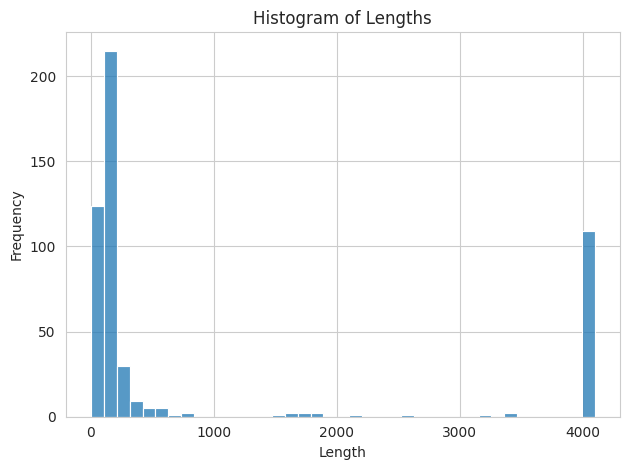

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assume lengths = [ ... ]  # your list of integers

sns.set_style("whitegrid")           # optional: nicer look
ax = sns.histplot(lengths_base, bins='auto', kde=False)

ax.set_xlabel("Length")
ax.set_ylabel("Frequency")
ax.set_title("Histogram of Lengths")

plt.tight_layout()
plt.show()


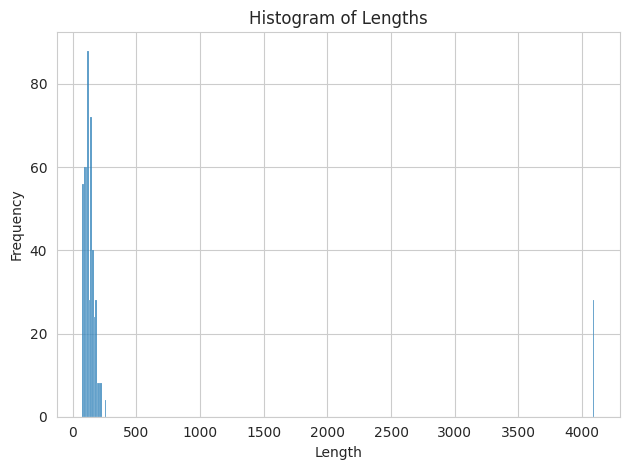

In [178]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assume lengths = [ ... ]  # your list of integers

sns.set_style("whitegrid")           # optional: nicer look
ax = sns.histplot(lengths, bins='auto', kde=False)

ax.set_xlabel("Length")
ax.set_ylabel("Frequency")
ax.set_title("Histogram of Lengths")

plt.tight_layout()
plt.show()


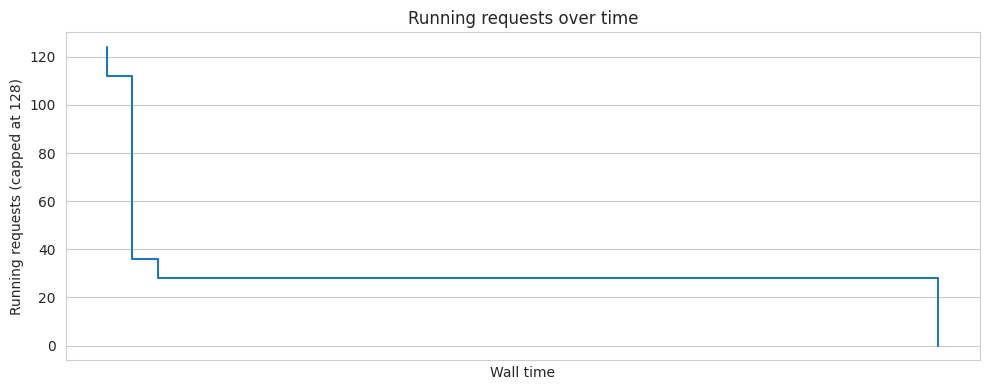

In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# queue_stat = [(timestamp, requests_left), ...]
df = pd.DataFrame(queue_stat, columns=["time", "requests_left"])

# make sure the timestamps are proper datetimes (remove this if they already are)
df["time"] = pd.to_datetime(df["time"])

# running requests = min(requests_left, 128)
df["running_requests"] = df["requests_left"].clip(upper=128)

sns.set_style("whitegrid")               # keep the look consistent
plt.figure(figsize=(10, 4))

# step plot is nice for queue sizes; swap to lineplot if ye prefer
plt.step(df["time"], df["running_requests"], where="post")
plt.ylabel("Running requests (capped at 128)")
plt.xlabel("Wall time")
plt.title("Running requests over time")

plt.tight_layout()
plt.show()


In [46]:
baseline_throughput = np.sum(lengths_base) / np.sum(durations_base)
ours_throughput = np.sum(lengths_ours) / np.sum(durations_ours)
partial_throughput = np.sum(lengths_partial) / np.sum(durations_partial)
print(f"Baseline throughput: {baseline_throughput:.2f} tokens/s")
print(f"Our throughput: {ours_throughput:.2f} tokens/s")
print(f"Partial throughput: {partial_throughput:.2f} tokens/s")

Baseline throughput: 3891.17 tokens/s
Our throughput: 4289.67 tokens/s
Partial throughput: 5559.37 tokens/s


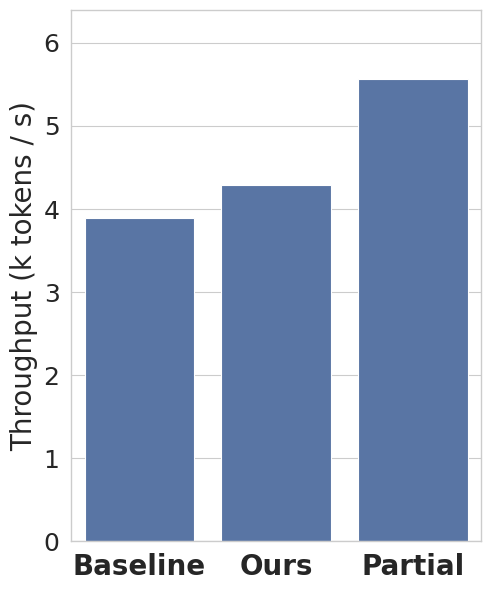

: 

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# — already computed —
# baseline_throughput, ours_throughput, partial_throughput

fontsize = 20

throughputs = [baseline_throughput, ours_throughput, partial_throughput]
throughputs = np.array(throughputs)
throughputs = throughputs / 1000  # convert to K tokens/s
labels      = ["Baseline", "Ours", "Partial"]

sns.set(style="whitegrid", context="paper")   # keeps look consistent with your other plots
plt.figure(figsize=(5, 6))

ax = sns.barplot(x=labels, y=throughputs)
ax.set_ylabel("Throughput (k tokens / s)", fontsize=fontsize)
ax.set_xlabel("")            # optional: bar labels speak for themselves
ax.set_ylim(0, max(throughputs) * 1.15)

plt.xticks(fontsize=20, weight="bold")
plt.yticks(fontsize=18)



plt.tight_layout()
plt.savefig("throughput.pdf", bbox_inches="tight")
plt.show()


/tmp/ipykernel_185497/1909159339.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


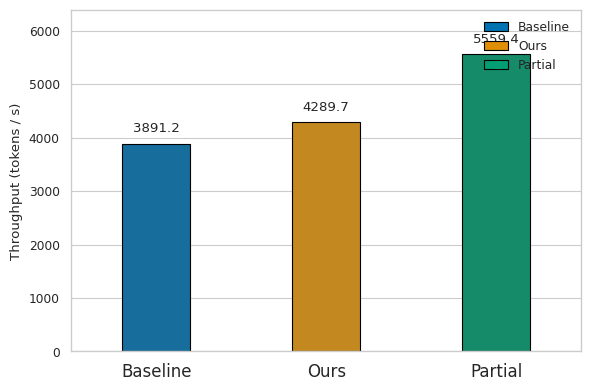

In [71]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch   # for custom legend entries

# — already computed —
# baseline_throughput, ours_throughput, partial_throughput

throughputs = [baseline_throughput, ours_throughput, partial_throughput]
labels      = ["Baseline", "Ours", "Partial"]

# choose a distinct, colour-blind-friendly palette
palette = sns.color_palette("colorblind", n_colors=3)

sns.set(style="whitegrid", context="paper")
plt.figure(figsize=(6, 4))

ax = sns.barplot(
    x=labels,
    y=throughputs,
    palette=palette,
    edgecolor="black",
    width=0.4,          # narrower bars → wider gaps
)

# enlarge x-tick labels
ax.tick_params(axis="x", labelsize=12)

ax.set_ylabel("Throughput (tokens / s)")
ax.set_xlabel("")
ax.set_ylim(0, max(throughputs) * 1.15)

# annotate bars
for i, v in enumerate(throughputs):
    ax.text(i, v + max(throughputs) * 0.03, f"{v:.1f}", ha="center", va="bottom")

# build a simple legend
legend_handles = [Patch(facecolor=palette[i], edgecolor="black", label=labels[i])
                  for i in range(len(labels))]
ax.legend(handles=legend_handles, frameon=False, loc="upper right")

plt.tight_layout()
plt.show()


In [99]:
torch.save(
    {
        'lengths_base': lengths_base,
        'lengths_ours': lengths_ours,
        'lengths_partial': lengths_partial,
        'durations_base': durations_base,
        'durations_ours': durations_ours,
        'durations_partial': durations_partial,
        'queue_stat_base': queue_stat_base,
        'queue_stat_ours': queue_stat_ours,
        'queue_stat_partial': queue_stat_partial,
    },
    "results.pth",
)

In [87]:
import pandas as pd

def queue_stat_to_df(queue_stat, queue_limit: int = 128, relative: bool = True) -> pd.DataFrame:
    """
    Map a list of (timestamp, pending_requests) tuples to a DataFrame with
    wall-time and running_requests (capped at `queue_limit`).

    Parameters
    ----------
    queue_stat : list[tuple[float | pd.Timestamp, int]]
        The raw samples.
    queue_limit : int, default 128
        Maximum number of requests that count as “running”.
    relative : bool, default True
        If True, convert timestamps to seconds since the first sample.
        If False, keep the original timestamps.

    Returns
    -------
    pd.DataFrame
        Columns: wall_time, running_requests
    """
    # Build initial dataframe
    df = pd.DataFrame(queue_stat, columns=["timestamp", "pending"])

    # Cap to the queue size
    df["running_requests"] = df["pending"].clip(upper=queue_limit)

    # Prepare wall-time axis
    if relative:
        t0 = df["timestamp"].iloc[0]
        if pd.api.types.is_datetime64_any_dtype(df["timestamp"]):
            df["wall_time"] = (df["timestamp"] - t0).dt.total_seconds()
        else:  # numeric seconds, Unix time, etc.
            df["wall_time"] = df["timestamp"] - t0
    else:
        df = df.rename(columns={"timestamp": "wall_time"})

    return df[["wall_time", "running_requests"]]


In [88]:
running_baseline = [queue_stat_to_df(qs) for qs in queue_stat_base]
running_ours = [queue_stat_to_df(qs) for qs in queue_stat_ours]
running_partial = [queue_stat_to_df(qs) for qs in queue_stat_partial]

In [89]:
import numpy as np
import pandas as pd

def bubble_ratio(df: pd.DataFrame, queue_limit: int = 128, trapz: bool = False) -> float:
    """
    Bubble ratio = ∫(queue_limit - running_requests) dt  /  (total_time * queue_limit)

    Parameters
    ----------
    df : pd.DataFrame
        Must contain 'wall_time' (seconds, monotonic) and 'running_requests'.
    queue_limit : int, default 128
        Maximum queue capacity.
    trapz : bool, default False
        If True, use the trapezoidal rule (np.trapz); otherwise use a left-Riemann sum.

    Returns
    -------
    float
        The bubble ratio in [0, 1].
    """
    # Ensure chronological ordering
    df = df.sort_values("wall_time").reset_index(drop=True)

    t = df["wall_time"].to_numpy()
    integrand = queue_limit - df["running_requests"].to_numpy()

    if trapz:
        bubble_area = np.trapz(integrand, t)
    else:                     # left-Riemann sum
        bubble_area = np.sum(integrand[:-1] * np.diff(t))

    total_time = t[-1] - t[0]
    return 0.0 if total_time == 0 else bubble_area / (total_time * queue_limit)


In [90]:
bubble_baseline = [bubble_ratio(df) for df in running_baseline]
bubble_ours = [bubble_ratio(df) for df in running_ours]
bubble_partial = [bubble_ratio(df) for df in running_partial]

In [104]:
mean_bubble_baseline = np.mean(bubble_baseline)
mean_bubble_ours = np.mean(bubble_ours)
mean_bubble_partial = np.mean(bubble_partial)

In [106]:
print(f"Mean bubble ratio (baseline): {mean_bubble_baseline:.2f}")
print(f"Mean bubble ratio (ours): {mean_bubble_ours:.4f}")
print(f"Mean bubble ratio (partial): {mean_bubble_partial:.4f}")

Mean bubble ratio (baseline): 0.74
Mean bubble ratio (ours): 0.0337
Mean bubble ratio (partial): 0.0581


In [149]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_running_requests(
    df,
    *,
    figsize=(4, 4),
    line_color="#4061a0",
    tick_fs=12,
    label_fs=18,
    xlim=None,
    ylim=None,
):
    """
    Draw a wall-time vs. running-requests line plot with seaborn.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain 'wall_time' and 'running_requests'.
    figsize : tuple, default (6, 4)
        Figure size in inches.
    line_color : str, default "#4061a0"
        Hex colour for the line.
    tick_fs : int, default 10
        Tick-label font size.
    label_fs : int, default 12
        Axis-label font size.
    xlim, ylim : tuple or None
        Optional axis limits (min, max).
    """
    sns.set_style("white")
    plt.figure(figsize=figsize)

    sns.lineplot(
        data=df,
        x="wall_time",
        y="running_requests",
        color=line_color,
        linewidth=2,
    )

    plt.xlabel("Wall time (s)", fontsize=label_fs)
    plt.ylabel("Running requests", fontsize=label_fs)
    plt.xticks(fontsize=tick_fs)
    plt.yticks(fontsize=tick_fs)

    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)

    plt.tight_layout()
    plt.savefig("running_requests.pdf", bbox_inches="tight")
    plt.show()


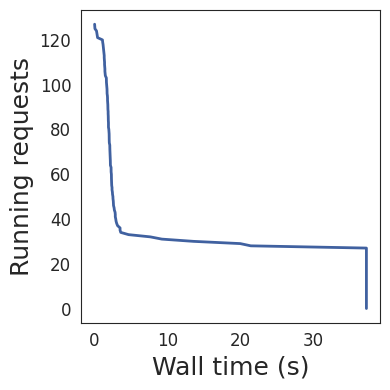

In [150]:
plot_running_requests(running_baseline[0])

In [112]:
queue_stat_acq = queue_stat

In [113]:
running_acq = queue_stat_to_df(queue_stat_acq)

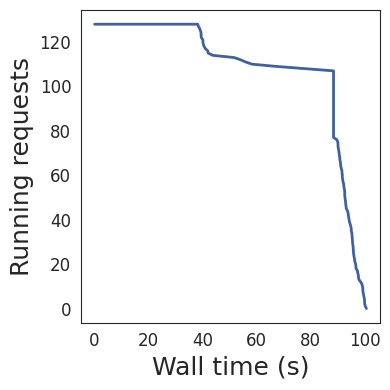

In [151]:
plot_running_requests(running_acq)

In [147]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_length_hist(
    lengths,
    *,
    bins="auto",
    kde=False,
    figsize=(4, 4),
    color="#4061a0",
    perc_color="#d0574e",   # colour for the percentile line
    tick_fs=12,
    label_fs=18,
    xlim=None,
    ylim=None,
    show_perc=True,         # toggle the auxiliary line
    percentile=95,          # which percentile to draw
):
    """
    Histogram of token lengths with an auxiliary percentile line.

    Parameters
    ----------
    lengths : list[int] | array-like
    percentile : float, default 95
        Percentile to mark with a vertical line.
    show_perc : bool, default True
        Draw the percentile line if True.
    All other args match the earlier version.
    """
    sns.set_style("white")
    plt.figure(figsize=figsize)

    # Core histogram
    sns.histplot(
        lengths,
        bins=bins,
        kde=kde,
        color=color,
        linewidth=1,
        alpha=0.8,
    )

    # Auxiliary percentile line
    if show_perc:
        perc_val = np.percentile(lengths, percentile)
        plt.axvline(
            perc_val,
            linestyle="--",
            linewidth=2,
            color=perc_color,
        )
        # plt.legend(fontsize=label_fs)

    plt.xlabel("Length", fontsize=label_fs)
    plt.ylabel("Frequency", fontsize=label_fs)
    plt.xticks(fontsize=tick_fs)
    plt.yticks(fontsize=tick_fs)

    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)

    sns.despine(trim=True)
    plt.tight_layout()
    plt.savefig("length_hist.pdf", bbox_inches="tight")
    plt.show()


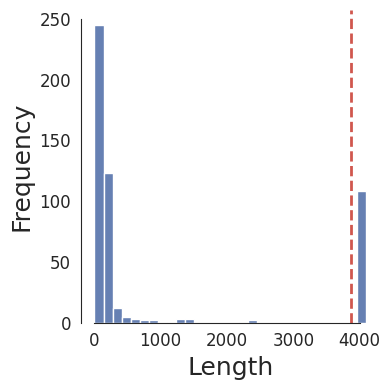

In [148]:
plot_length_hist(lengths_base, bins=30, percentile=79)